# Figures for IRES seminar on 2024-12-05

In [2]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import scipy.stats as stats
from sklearn import linear_model
import statsmodels.api as sm
import seaborn as sns

from cartopy import crs as ccrs, feature as cfeature
import netCDF4
from netCDF4 import Dataset
from datetime import datetime as dt

# to get rid of runtime warnings when OLS fits hit a divide by zero - handled by setting R2 and p-vals appropriately
import warnings
warnings.filterwarnings('ignore')

In [3]:
# read in summer stats
input_path = '../../../Data/ERA5-global/Analysis/New/1961-2023_ALL_summer_stats.nc'
ds_full = xr.open_dataset(input_path)

# generate weights for any spatial averages
# (this is a regular grid so we can use cos(latitude))
weights = np.cos(np.deg2rad(ds_full.lat))
weights.name = "weights"

ds_full


<xarray.Dataset> Size: 5GB
Dimensions:       (lat: 721, lon: 1440, time: 63)
Coordinates:
  * lat           (lat) float64 6kB -90.0 -89.75 -89.5 ... 89.5 89.75 90.0
  * lon           (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.2 179.5 179.8
  * time          (time) datetime64[ns] 504B 1961-01-01 ... 2023-01-01
Data variables:
    SummerStart   (time, lat, lon) float64 523MB ...
    SummerEnd     (time, lat, lon) float64 523MB ...
    SummerTmax    (time, lat, lon) float64 523MB ...
    SummerHeat    (time, lat, lon) float64 523MB ...
    SummerLength  (time, lat, lon) float64 523MB ...
    SummerRMSE    (time, lat, lon) float64 523MB ...
    SummerR2      (time, lat, lon) float64 523MB ...
    SummerMeanT   (time, lat, lon) float64 523MB ...
    SummerMeanHS  (time, lat, lon) float64 523MB ...
    lsm           (time, lat, lon) float64 523MB ...
    Coastal       (time, lat, lon) bool 65MB ...

NameError: name 'ds_full' is not defined

In [21]:
# Summer Data broken into variables
ds_full_length = ds_full.SummerLength
ds_full_start = ds_full.SummerStart
ds_full_end = ds_full.SummerEnd

## Summer Length Data for violin and scatter plots

In [22]:
ds_base = ds_full_length.sel(time=slice('1961','1990'))
ds = ds_full_length.sel(time=slice('1994','2023'))

Van p-val: 0.0001
Tor p-val: 0.0041
Bei p-val: 0.0
Gua p-val: 0.0002
Syd p-val: 0.0014
CTn p-val: 0.2158
Phx p-val: 0.0
NwD p-val: 0.0842


(20.0, 150.0)

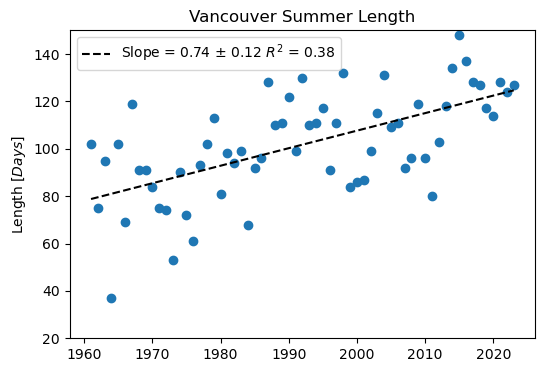

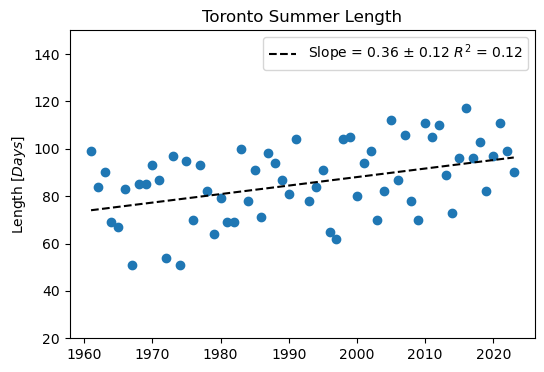

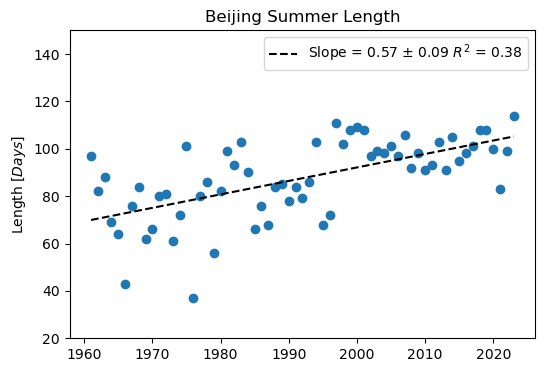

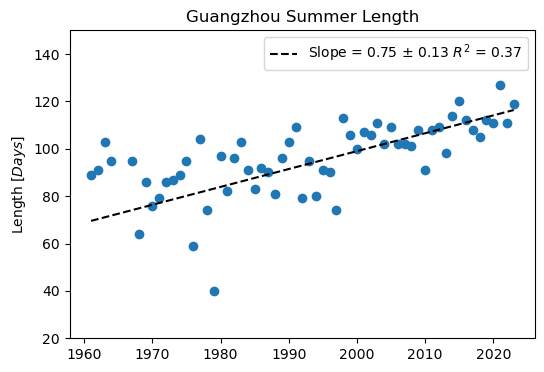

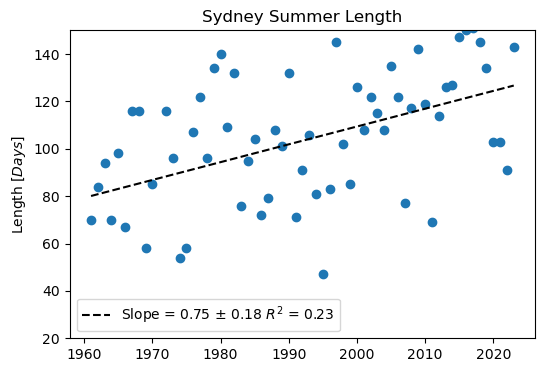

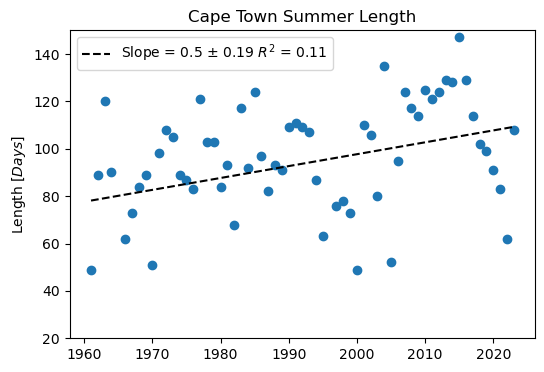

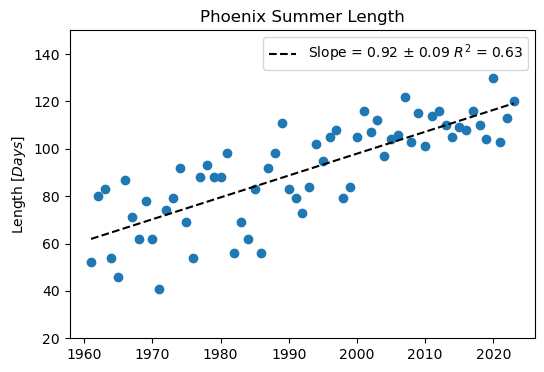

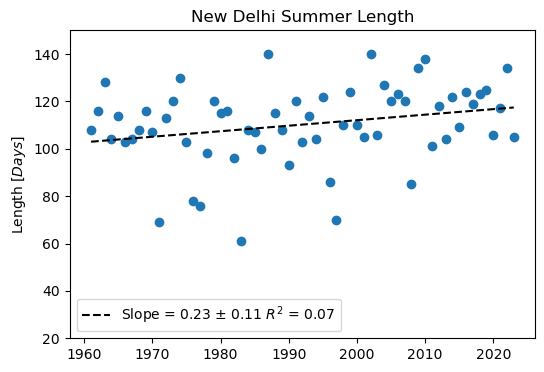

In [23]:

# Vancouver
input_lat = 49.246
input_lon = -123.116
van_length_analysis = ds.sel(lat=input_lat, lon=input_lon, method="nearest")
van_length_base = ds_base.sel(lat=input_lat, lon=input_lon, method="nearest")
# t-test
statres, pval = stats.ttest_rel(van_length_analysis, van_length_base)
print("Van p-val: "+str(np.round(pval,4)))

# plot the time series of Summer Length for Vancouver w/ linear fit
x = ds_full_length.time.dt.year.values
y = ds_full_length.sel(lat=input_lat, lon=input_lon, method='nearest').values
coefs, V = np.polyfit(x, y, 1, cov=True)
poly = np.poly1d(coefs)
slope = np.round(coefs[0],2)
slope_sd = np.round(np.sqrt(V[0][0]),2)  
# add in R^2 and RMSE
ymean = np.mean(y)
ss_total = np.sum((y - ymean)**2)
ss_res = np.sum((y - poly(x))**2)
#rmse = np.sqrt(ss_res/365.0)
r_squared = np.round(1 - (ss_res / ss_total),2)
plt.figure(figsize=(6,4))
plt.scatter(x, y)
plt.plot(x, poly(x), linestyle="dashed", color='k', 
         label="Slope = "+str(slope)+" $\pm$ "+str(slope_sd)+" $R^2$ = "+str(r_squared))
plt.title("Vancouver Summer Length")
plt.ylabel("Length [$Days$]")
plt.legend(loc='best')
plt.ylim(20,150)

# Toronto
# 43°45'03"N 79°28'55"W is roughly the middle from google earth
input_lat = 43 + 45/60
input_lon = -79 -29/60
tor_length_analysis = ds.sel(lat=input_lat, lon=input_lon, method="nearest")
tor_length_base = ds_base.sel(lat=input_lat, lon=input_lon, method="nearest")
# t-test
statres, pval = stats.ttest_rel(tor_length_analysis, tor_length_base)
print("Tor p-val: "+str(np.round(pval,4)))

# plot the time series of Summer Length for Toronto
x = ds_full_length.time.dt.year.values
y = ds_full_length.sel(lat=input_lat, lon=input_lon, method='nearest').values
coefs, V = np.polyfit(x, y, 1, cov=True)
poly = np.poly1d(coefs)
slope = np.round(coefs[0],2)
slope_sd = np.round(np.sqrt(V[0][0]),2)  
# add in R^2 and RMSE
ymean = np.mean(y)
ss_total = np.sum((y - ymean)**2)
ss_res = np.sum((y - poly(x))**2)
#rmse = np.sqrt(ss_res/365.0)
r_squared = np.round(1 - (ss_res / ss_total),2)
plt.figure(figsize=(6,4))
plt.scatter(x, y)
plt.plot(x, poly(x), linestyle="dashed", color='k', 
         label="Slope = "+str(slope)+" $\pm$ "+str(slope_sd)+" $R^2$ = "+str(r_squared))
plt.title("Toronto Summer Length")
plt.ylabel("Length [$Days$]")
plt.legend(loc='best')
plt.ylim(20,150)

# Beijing
input_lat = 39.9075
input_lon = 116.39723
bei_length_analysis = ds.sel(lat=input_lat, lon=input_lon, method="nearest")
bei_length_base = ds_base.sel(lat=input_lat, lon=input_lon, method="nearest")
# t-test
statres, pval = stats.ttest_rel(bei_length_analysis, bei_length_base)
print("Bei p-val: "+str(np.round(pval,4)))

# plot the time series of Summer Length for Beijing
x = ds_full_length.time.dt.year.values
y = ds_full_length.sel(lat=input_lat, lon=input_lon, method='nearest').values
coefs, V = np.polyfit(x, y, 1, cov=True)
poly = np.poly1d(coefs)
slope = np.round(coefs[0],2)
slope_sd = np.round(np.sqrt(V[0][0]),2)  
# add in R^2 and RMSE
ymean = np.mean(y)
ss_total = np.sum((y - ymean)**2)
ss_res = np.sum((y - poly(x))**2)
#rmse = np.sqrt(ss_res/365.0)
r_squared = np.round(1 - (ss_res / ss_total),2)
plt.figure(figsize=(6,4))
plt.scatter(x, y)
plt.plot(x, poly(x), linestyle="dashed", color='k', 
         label="Slope = "+str(slope)+" $\pm$ "+str(slope_sd)+" $R^2$ = "+str(r_squared))
plt.title("Beijing Summer Length")
plt.ylabel("Length [$Days$]")
plt.legend(loc='best')
plt.ylim(20,150)


# Guangzhou
# 112° 57′ to 114° 03′ E longitude and 22° 26′ to 23° 56′ N latitude
input_lat = 22 + 45/60 # midpoint of those latitude values above
input_lon = 113.5 # midpoint of those longitudes above
gua_length_analysis = ds.sel(lat=input_lat, lon=input_lon, method="nearest")
gua_length_base = ds_base.sel(lat=input_lat, lon=input_lon, method="nearest")
# t-test
statres, pval = stats.ttest_rel(gua_length_analysis, gua_length_base)
print("Gua p-val: "+str(np.round(pval,4)))

# plot the time series of Summer Length for Guangzhou
x = ds_full_length.time.dt.year.values
y = ds_full_length.sel(lat=input_lat, lon=input_lon, method='nearest').values
coefs, V = np.polyfit(x, y, 1, cov=True)
poly = np.poly1d(coefs)
slope = np.round(coefs[0],2)
slope_sd = np.round(np.sqrt(V[0][0]),2)  
# add in R^2 and RMSE
ymean = np.mean(y)
ss_total = np.sum((y - ymean)**2)
ss_res = np.sum((y - poly(x))**2)
#rmse = np.sqrt(ss_res/365.0)
r_squared = np.round(1 - (ss_res / ss_total),2)
plt.figure(figsize=(6,4))
plt.scatter(x, y)
plt.plot(x, poly(x), linestyle="dashed", color='k', 
         label="Slope = "+str(slope)+" $\pm$ "+str(slope_sd)+" $R^2$ = "+str(r_squared))
plt.title("Guangzhou Summer Length")
plt.ylabel("Length [$Days$]")
plt.legend(loc='best')
plt.ylim(20,150)

# Sydney, NSW
input_lat = -33.86785
input_lon = 151.083
syd_length_analysis = ds.sel(lat=input_lat, lon=input_lon, method="nearest")
syd_length_base = ds_base.sel(lat=input_lat, lon=input_lon, method="nearest")
# t-test
statres, pval = stats.ttest_rel(syd_length_analysis, syd_length_base)
print("Syd p-val: "+str(np.round(pval,4)))

# plot the time series of Summer Length for Sydney
x = ds_full_length.time.dt.year.values
y = ds_full_length.sel(lat=input_lat, lon=input_lon, method='nearest').values
coefs, V = np.polyfit(x, y, 1, cov=True)
poly = np.poly1d(coefs)
slope = np.round(coefs[0],2)
slope_sd = np.round(np.sqrt(V[0][0]),2)  
# add in R^2 and RMSE
ymean = np.mean(y)
ss_total = np.sum((y - ymean)**2)
ss_res = np.sum((y - poly(x))**2)
#rmse = np.sqrt(ss_res/365.0)
r_squared = np.round(1 - (ss_res / ss_total),2)
plt.figure(figsize=(6,4))
plt.scatter(x, y)
plt.plot(x, poly(x), linestyle="dashed", color='k', 
         label="Slope = "+str(slope)+" $\pm$ "+str(slope_sd)+" $R^2$ = "+str(r_squared))
plt.title("Sydney Summer Length")
plt.ylabel("Length [$Days$]")
plt.legend(loc='best')
plt.ylim(20,150)

# Cape Town
input_lat = -33.95
input_lon = 18+32/60
ctn_length_analysis = ds.sel(lat=input_lat, lon=input_lon, method="nearest")
ctn_length_base = ds_base.sel(lat=input_lat, lon=input_lon, method="nearest")
# t-test
statres, pval = stats.ttest_rel(ctn_length_analysis, ctn_length_base)
print("CTn p-val: "+str(np.round(pval,4)))

# plot the time series of Summer Length for Cape Town
x = ds_full_length.time.dt.year.values
y = ds_full_length.sel(lat=input_lat, lon=input_lon, method='nearest').values
coefs, V = np.polyfit(x, y, 1, cov=True)
poly = np.poly1d(coefs)
slope = np.round(coefs[0],2)
slope_sd = np.round(np.sqrt(V[0][0]),2)  
# add in R^2 and RMSE
ymean = np.mean(y)
ss_total = np.sum((y - ymean)**2)
ss_res = np.sum((y - poly(x))**2)
#rmse = np.sqrt(ss_res/365.0)
r_squared = np.round(1 - (ss_res / ss_total),2)
plt.figure(figsize=(6,4))
plt.scatter(x, y)
plt.plot(x, poly(x), linestyle="dashed", color='k', 
         label="Slope = "+str(slope)+" $\pm$ "+str(slope_sd)+" $R^2$ = "+str(r_squared))
plt.title("Cape Town Summer Length")
plt.ylabel("Length [$Days$]")
plt.legend(loc='best')
plt.ylim(20,150)

# Phoenix
input_lat = 33+28/60
input_lon = -112 - 4/60
phx_length_analysis = ds.sel(lat=input_lat, lon=input_lon, method="nearest")
phx_length_base = ds_base.sel(lat=input_lat, lon=input_lon, method="nearest")
# t-test
statres, pval = stats.ttest_rel(phx_length_analysis, phx_length_base)
print("Phx p-val: "+str(np.round(pval,4)))

# plot the time series of Summer Length for Phoenix
x = ds_full_length.time.dt.year.values
y = ds_full_length.sel(lat=input_lat, lon=input_lon, method='nearest').values
coefs, V = np.polyfit(x, y, 1, cov=True)
poly = np.poly1d(coefs)
slope = np.round(coefs[0],2)
slope_sd = np.round(np.sqrt(V[0][0]),2)  
# add in R^2 and RMSE
ymean = np.mean(y)
ss_total = np.sum((y - ymean)**2)
ss_res = np.sum((y - poly(x))**2)
#rmse = np.sqrt(ss_res/365.0)
r_squared = np.round(1 - (ss_res / ss_total),2)
plt.figure(figsize=(6,4))
plt.scatter(x, y)
plt.plot(x, poly(x), linestyle="dashed", color='k', 
         label="Slope = "+str(slope)+" $\pm$ "+str(slope_sd)+" $R^2$ = "+str(r_squared))
plt.title("Phoenix Summer Length")
plt.ylabel("Length [$Days$]")
plt.legend(loc='best')
plt.ylim(20,150)

# New Delhi
input_lat = 28+37/60
input_lon = 77 + 13/60
nwd_length_analysis = ds.sel(lat=input_lat, lon=input_lon, method="nearest")
nwd_length_base = ds_base.sel(lat=input_lat, lon=input_lon, method="nearest")
# t-test
statres, pval = stats.ttest_rel(nwd_length_analysis, nwd_length_base)
print("NwD p-val: "+str(np.round(pval,4)))

# plot the time series of Summer Length for New Delhi
x = ds_full_length.time.dt.year.values
y = ds_full_length.sel(lat=input_lat, lon=input_lon, method='nearest').values
coefs, V = np.polyfit(x, y, 1, cov=True)
poly = np.poly1d(coefs)
slope = np.round(coefs[0],2)
slope_sd = np.round(np.sqrt(V[0][0]),2)  
# add in R^2 and RMSE
ymean = np.mean(y)
ss_total = np.sum((y - ymean)**2)
ss_res = np.sum((y - poly(x))**2)
#rmse = np.sqrt(ss_res/365.0)
r_squared = np.round(1 - (ss_res / ss_total),2)
plt.figure(figsize=(6,4))
plt.scatter(x, y)
plt.plot(x, poly(x), linestyle="dashed", color='k', 
         label="Slope = "+str(slope)+" $\pm$ "+str(slope_sd)+" $R^2$ = "+str(r_squared))
plt.title("New Delhi Summer Length")
plt.ylabel("Length [$Days$]")
plt.legend(loc='best')
plt.ylim(20,150)


### The Summer Length Violin plots - 2 cities compared each time

#### Van vs Toronto

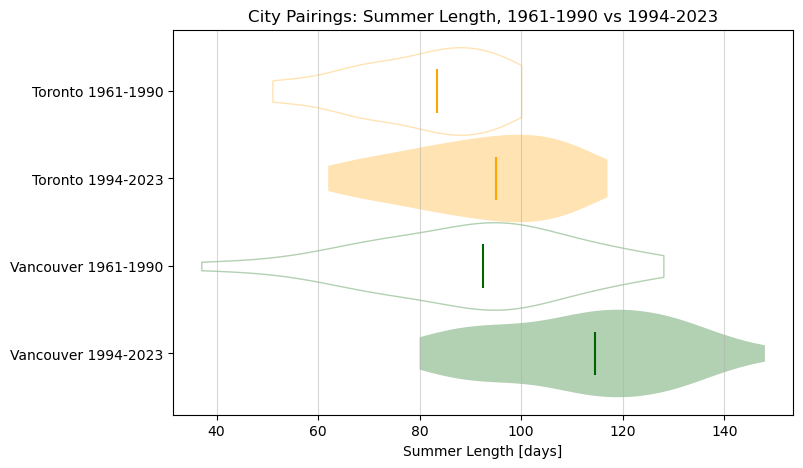

In [24]:
# violin plot customization from https://stackoverflow.com/questions/26291479/changing-the-color-of-matplotlibs-violin-plots
labels=['Vancouver 1994-2023','Vancouver 1961-1990',
        'Toronto 1994-2023','Toronto 1961-1990'
        ]

colors = ['darkgreen','darkgreen','orange','orange']#,'gray','gray','red','red','purple','purple']
data = [van_length_analysis, van_length_base, 
        tor_length_analysis, tor_length_base
       ]


fig, ax = plt.subplots(1, 1, figsize=(8,5))
plots = ax.violinplot(data, vert=False, showmedians=True, showextrema=False, widths=1)
for i, (pc,color) in enumerate(zip(plots['bodies'], colors)):
    if i % 2 == 0:
        pc.set_facecolor(color)
    else:
        pc.set_edgecolor(color)
        pc.set_facecolor('white')

# Set the color of the median lines
plots['cmedians'].set_colors(colors)

ax.set_xlabel("Summer Length [days]")
ax.set_yticks(np.arange(1,len(labels)+1),labels=labels)
#ax.set_xticks(np.arange(140,300,10))
plt.grid(axis="x", which='both', alpha=0.5)
plt.title("City Pairings: Summer Length, 1961-1990 vs 1994-2023")
plt.show()


In [8]:
print("Toronto Change in Median Summer Length: " + str(float(tor_length_analysis.median() - tor_length_base.median())) + " days")
print("Van Change in Median Summer Length: " + str(float(van_length_analysis.median() - van_length_base.median())) + " days")

Toronto Change in Median Summer Length: 11.5 days
Van Change in Median Summer Length: 22.0 days


#### Beijing vs Guangzhou

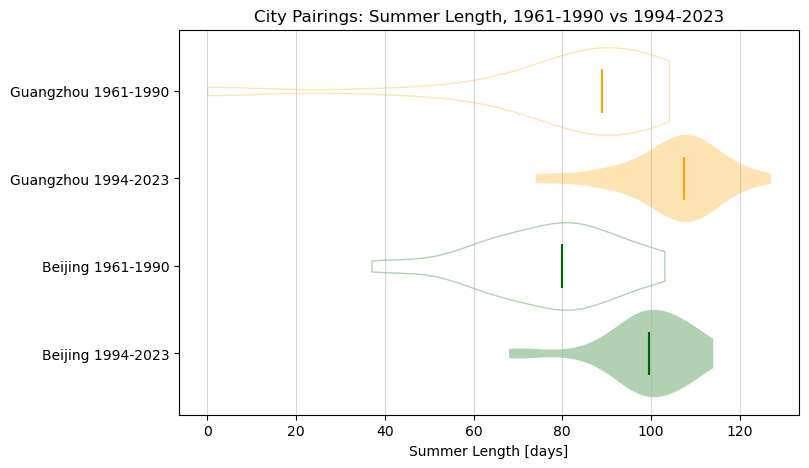

In [25]:
# violin plot customization from https://stackoverflow.com/questions/26291479/changing-the-color-of-matplotlibs-violin-plots
labels=['Beijing 1994-2023','Beijing 1961-1990',
        'Guangzhou 1994-2023','Guangzhou 1961-1990'
        ]

colors = ['darkgreen','darkgreen','orange','orange']#,'gray','gray','red','red','purple','purple']
data = [bei_length_analysis, bei_length_base, 
        gua_length_analysis, gua_length_base
       ]


fig, ax = plt.subplots(1, 1, figsize=(8,5))
plots = ax.violinplot(data, vert=False, showmedians=True, showextrema=False, widths=1)
for i, (pc,color) in enumerate(zip(plots['bodies'], colors)):
    if i % 2 == 0:
        pc.set_facecolor(color)
    else:
        pc.set_edgecolor(color)
        pc.set_facecolor('white')

# Set the color of the median lines
plots['cmedians'].set_colors(colors)

ax.set_xlabel("Summer Length [days]")
ax.set_yticks(np.arange(1,len(labels)+1),labels=labels)
#ax.set_xticks(np.arange(140,300,10))
plt.grid(axis="x", which='both', alpha=0.5)
plt.title("City Pairings: Summer Length, 1961-1990 vs 1994-2023")
plt.show()


In [10]:
print("Beijing Change in Median Summer Length: " + str(float(bei_length_analysis.median() - bei_length_base.median())) + " days")
print("Guangzhou Change in Median Summer Length: " + str(float(gua_length_analysis.median() - gua_length_base.median())) + " days")

Beijing Change in Median Summer Length: 19.5 days
Guangzhou Change in Median Summer Length: 18.5 days


#### I suspect that is within any confidence bands around the median estimate

In [26]:
gua_length_base

<xarray.DataArray 'SummerLength' (time: 30)> Size: 240B
array([ 89.,  91., 103.,  95.,   0.,   0.,  95.,  64.,  86.,  76.,  79.,  86.,
        87.,  89.,  95.,  59., 104.,  74.,  40.,  97.,  82.,  96., 103.,  91.,
        83.,  92.,  90.,  81.,  96., 103.])
Coordinates:
    lat      float64 8B 22.75
    lon      float64 8B 113.5
  * time     (time) datetime64[ns] 240B 1961-01-01 1962-01-01 ... 1990-01-01
Attributes:
    long_name:  Duration of summer for the year
    units:      Days

#### Phoenix vs New Delhi

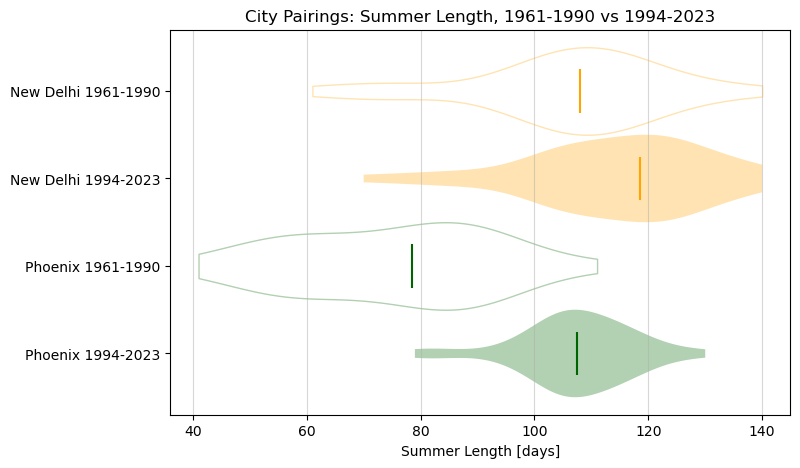

In [27]:
# violin plot customization from https://stackoverflow.com/questions/26291479/changing-the-color-of-matplotlibs-violin-plots
labels=['Phoenix 1994-2023','Phoenix 1961-1990',
        'New Delhi 1994-2023','New Delhi 1961-1990'
        ]

colors = ['darkgreen','darkgreen','orange','orange']#,'gray','gray','red','red','purple','purple']
data = [phx_length_analysis, phx_length_base, 
        nwd_length_analysis, nwd_length_base
       ]


fig, ax = plt.subplots(1, 1, figsize=(8,5))
plots = ax.violinplot(data, vert=False, showmedians=True, showextrema=False, widths=1)
for i, (pc,color) in enumerate(zip(plots['bodies'], colors)):
    if i % 2 == 0:
        pc.set_facecolor(color)
    else:
        pc.set_edgecolor(color)
        pc.set_facecolor('white')

# Set the color of the median lines
plots['cmedians'].set_colors(colors)

ax.set_xlabel("Summer Length [days]")
ax.set_yticks(np.arange(1,len(labels)+1),labels=labels)
#ax.set_xticks(np.arange(140,300,10))
plt.grid(axis="x", which='both', alpha=0.5)
plt.title("City Pairings: Summer Length, 1961-1990 vs 1994-2023")
plt.show()


In [18]:
print("Phoenix Change in Median Summer Length: " + str(float(phx_length_analysis.median() - phx_length_base.median())) + " days")
print("New Delhi Change in Median Summer Length: " + str(float(nwd_length_analysis.median() - nwd_length_base.median())) + " days")

Phoenix Change in Median Summer Length: 29.0 days
New Delhi Change in Median Summer Length: 10.5 days


## Summer Start Data for violin and scatter plots

In [28]:
ds_base = ds_full_start.sel(time=slice('1961','1990'))
ds = ds_full_start.sel(time=slice('1994','2023'))

In [63]:
#ds_base

Van p-val: 0.0011
Tor p-val: 0.0371
Bei p-val: 0.0
Gua p-val: 0.7248
Syd p-val: 0.0003
CTn p-val: 0.3046
Phx p-val: 0.0
NwD p-val: 0.2726


(100.0, 250.0)

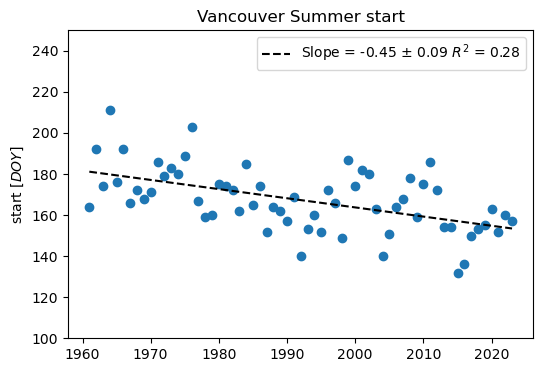

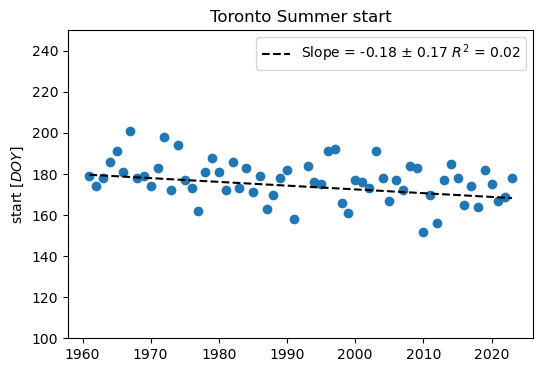

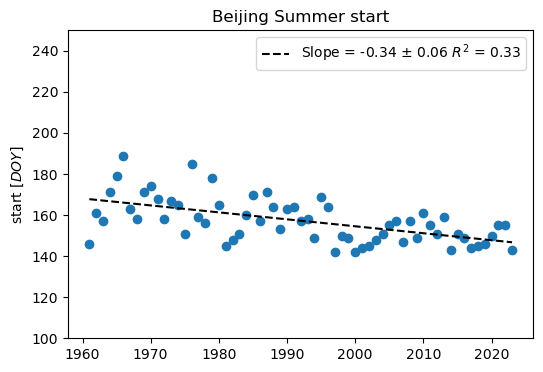

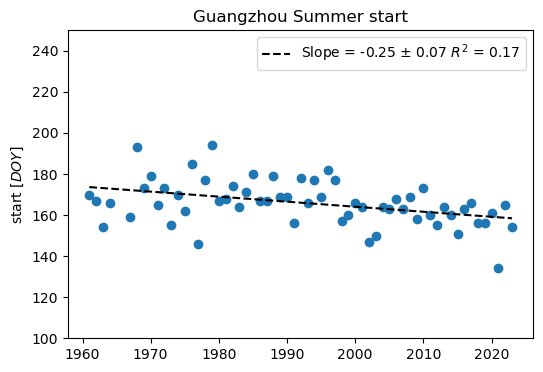

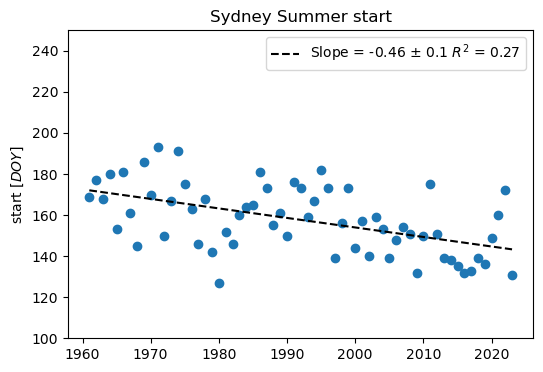

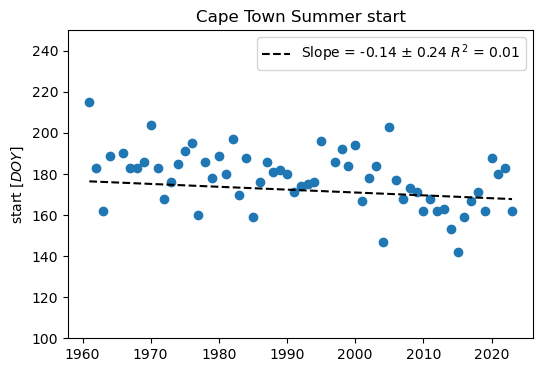

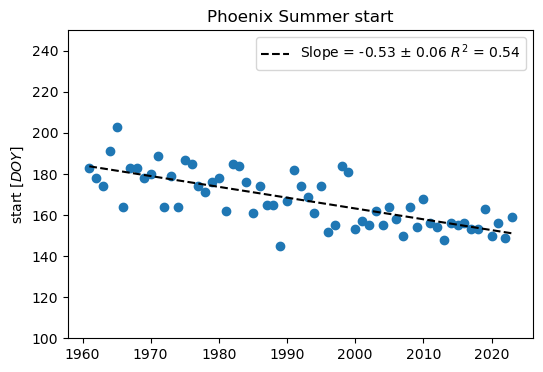

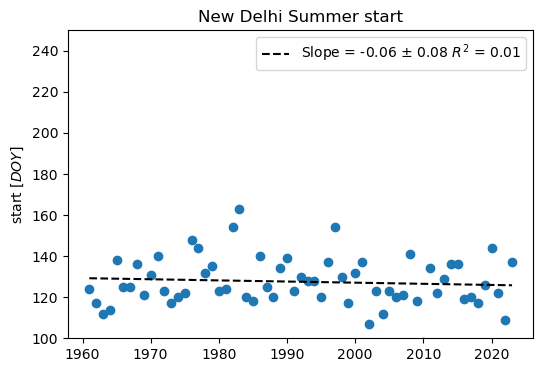

In [29]:

# Vancouver
input_lat = 49.246
input_lon = -123.116
van_start_analysis = ds.sel(lat=input_lat, lon=input_lon, method="nearest")
van_start_base = ds_base.sel(lat=input_lat, lon=input_lon, method="nearest")
# t-test
statres, pval = stats.ttest_rel(van_start_analysis, van_start_base)
print("Van p-val: "+str(np.round(pval,4)))

# plot the time series of Summer start for Vancouver w/ linear fit
x = ds_full_start.time.dt.year.values
y = ds_full_start.sel(lat=input_lat, lon=input_lon, method='nearest').values
coefs, V = np.polyfit(x, y, 1, cov=True)
poly = np.poly1d(coefs)
slope = np.round(coefs[0],2)
slope_sd = np.round(np.sqrt(V[0][0]),2)  
# add in R^2 and RMSE
ymean = np.mean(y)
ss_total = np.sum((y - ymean)**2)
ss_res = np.sum((y - poly(x))**2)
#rmse = np.sqrt(ss_res/365.0)
r_squared = np.round(1 - (ss_res / ss_total),2)
plt.figure(figsize=(6,4))
plt.scatter(x, y)
plt.plot(x, poly(x), linestyle="dashed", color='k', 
         label="Slope = "+str(slope)+" $\pm$ "+str(slope_sd)+" $R^2$ = "+str(r_squared))
plt.title("Vancouver Summer start")
plt.ylabel("start [$DOY$]")
plt.legend(loc='best')
plt.ylim(100,250)

# Toronto
# 43°45'03"N 79°28'55"W is roughly the middle from google earth
input_lat = 43 + 45/60
input_lon = -79 -29/60
tor_start_analysis = ds.sel(lat=input_lat, lon=input_lon, method="nearest")
tor_start_base = ds_base.sel(lat=input_lat, lon=input_lon, method="nearest")
# t-test
statres, pval = stats.ttest_rel(tor_start_analysis, tor_start_base)
print("Tor p-val: "+str(np.round(pval,4)))

# plot the time series of Summer start for Toronto
x = ds_full_start.time.dt.year.values
y = ds_full_start.sel(lat=input_lat, lon=input_lon, method='nearest').values
coefs, V = np.polyfit(x, y, 1, cov=True)
poly = np.poly1d(coefs)
slope = np.round(coefs[0],2)
slope_sd = np.round(np.sqrt(V[0][0]),2)  
# add in R^2 and RMSE
ymean = np.mean(y)
ss_total = np.sum((y - ymean)**2)
ss_res = np.sum((y - poly(x))**2)
#rmse = np.sqrt(ss_res/365.0)
r_squared = np.round(1 - (ss_res / ss_total),2)
plt.figure(figsize=(6,4))
plt.scatter(x, y)
plt.plot(x, poly(x), linestyle="dashed", color='k', 
         label="Slope = "+str(slope)+" $\pm$ "+str(slope_sd)+" $R^2$ = "+str(r_squared))
plt.title("Toronto Summer start")
plt.ylabel("start [$DOY$]")
plt.legend(loc='best')
plt.ylim(100,250)

# Beijing
input_lat = 39.9075
input_lon = 116.39723
bei_start_analysis = ds.sel(lat=input_lat, lon=input_lon, method="nearest")
bei_start_base = ds_base.sel(lat=input_lat, lon=input_lon, method="nearest")
# t-test
statres, pval = stats.ttest_rel(bei_start_analysis, bei_start_base)
print("Bei p-val: "+str(np.round(pval,4)))

# plot the time series of Summer start for Beijing
x = ds_full_start.time.dt.year.values
y = ds_full_start.sel(lat=input_lat, lon=input_lon, method='nearest').values
coefs, V = np.polyfit(x, y, 1, cov=True)
poly = np.poly1d(coefs)
slope = np.round(coefs[0],2)
slope_sd = np.round(np.sqrt(V[0][0]),2)  
# add in R^2 and RMSE
ymean = np.mean(y)
ss_total = np.sum((y - ymean)**2)
ss_res = np.sum((y - poly(x))**2)
#rmse = np.sqrt(ss_res/365.0)
r_squared = np.round(1 - (ss_res / ss_total),2)
plt.figure(figsize=(6,4))
plt.scatter(x, y)
plt.plot(x, poly(x), linestyle="dashed", color='k', 
         label="Slope = "+str(slope)+" $\pm$ "+str(slope_sd)+" $R^2$ = "+str(r_squared))
plt.title("Beijing Summer start")
plt.ylabel("start [$DOY$]")
plt.legend(loc='best')
plt.ylim(100,250)


# Guangzhou
# 112° 57′ to 114° 03′ E longitude and 22° 26′ to 23° 56′ N latitude
input_lat = 22 + 45/60 # midpoint of those latitude values above
input_lon = 113.5 # midpoint of those longitudes above
gua_start_analysis = ds.sel(lat=input_lat, lon=input_lon, method="nearest")
gua_start_base = ds_base.sel(lat=input_lat, lon=input_lon, method="nearest")
# t-test
statres, pval = stats.ttest_rel(gua_start_analysis, gua_start_base)
print("Gua p-val: "+str(np.round(pval,4)))

# plot the time series of Summer start for Guangzhou
x = ds_full_start.time.dt.year.values
y = ds_full_start.where(ds_full_start > 0).sel(lat=input_lat, lon=input_lon, method='nearest').values

# deal with nan
idx = np.isfinite(x) & np.isfinite(y)
coefs, V = np.polyfit(x[idx], y[idx], 1, cov=True)

#coefs, V = np.polyfit(x, y, 1, cov=True)
poly = np.poly1d(coefs)
slope = np.round(coefs[0],2)
slope_sd = np.round(np.sqrt(V[0][0]),2)  
# add in R^2 and RMSE
ymean = np.mean(y[idx])
ss_total = np.sum((y[idx] - ymean)**2)
ss_res = np.sum((y[idx] - poly(x[idx]))**2)
#rmse = np.sqrt(ss_res/365.0)
r_squared = np.round(1 - (ss_res / ss_total),2)
plt.figure(figsize=(6,4))
plt.scatter(x[idx], y[idx])
plt.plot(x[idx], poly(x[idx]), linestyle="dashed", color='k', 
         label="Slope = "+str(slope)+" $\pm$ "+str(slope_sd)+" $R^2$ = "+str(r_squared))
plt.title("Guangzhou Summer start")
plt.ylabel("start [$DOY$]")
plt.legend(loc='best')
plt.ylim(100,250)

# Sydney, NSW
input_lat = -33.86785
input_lon = 151.083
syd_start_analysis = ds.sel(lat=input_lat, lon=input_lon, method="nearest")
syd_start_base = ds_base.sel(lat=input_lat, lon=input_lon, method="nearest")
# t-test
statres, pval = stats.ttest_rel(syd_start_analysis, syd_start_base)
print("Syd p-val: "+str(np.round(pval,4)))

# plot the time series of Summer start for Sydney
x = ds_full_start.time.dt.year.values
y = ds_full_start.sel(lat=input_lat, lon=input_lon, method='nearest').values
coefs, V = np.polyfit(x, y, 1, cov=True)
poly = np.poly1d(coefs)
slope = np.round(coefs[0],2)
slope_sd = np.round(np.sqrt(V[0][0]),2)  
# add in R^2 and RMSE
ymean = np.mean(y)
ss_total = np.sum((y - ymean)**2)
ss_res = np.sum((y - poly(x))**2)
#rmse = np.sqrt(ss_res/365.0)
r_squared = np.round(1 - (ss_res / ss_total),2)
plt.figure(figsize=(6,4))
plt.scatter(x, y)
plt.plot(x, poly(x), linestyle="dashed", color='k', 
         label="Slope = "+str(slope)+" $\pm$ "+str(slope_sd)+" $R^2$ = "+str(r_squared))
plt.title("Sydney Summer start")
plt.ylabel("start [$DOY$]")
plt.legend(loc='best')
plt.ylim(100,250)

# Cape Town
input_lat = -33.95
input_lon = 18+32/60
ctn_start_analysis = ds.sel(lat=input_lat, lon=input_lon, method="nearest")
ctn_start_base = ds_base.sel(lat=input_lat, lon=input_lon, method="nearest")
# t-test
statres, pval = stats.ttest_rel(ctn_start_analysis, ctn_start_base)
print("CTn p-val: "+str(np.round(pval,4)))

# plot the time series of Summer start for Cape Town
x = ds_full_start.time.dt.year.values
y = ds_full_start.sel(lat=input_lat, lon=input_lon, method='nearest').values
coefs, V = np.polyfit(x, y, 1, cov=True)
poly = np.poly1d(coefs)
slope = np.round(coefs[0],2)
slope_sd = np.round(np.sqrt(V[0][0]),2)  
# add in R^2 and RMSE
ymean = np.mean(y)
ss_total = np.sum((y - ymean)**2)
ss_res = np.sum((y - poly(x))**2)
#rmse = np.sqrt(ss_res/365.0)
r_squared = np.round(1 - (ss_res / ss_total),2)
plt.figure(figsize=(6,4))
plt.scatter(x, y)
plt.plot(x, poly(x), linestyle="dashed", color='k', 
         label="Slope = "+str(slope)+" $\pm$ "+str(slope_sd)+" $R^2$ = "+str(r_squared))
plt.title("Cape Town Summer start")
plt.ylabel("start [$DOY$]")
plt.legend(loc='best')
plt.ylim(100,250)

# Phoenix
input_lat = 33+28/60
input_lon = -112 - 4/60
phx_start_analysis = ds.sel(lat=input_lat, lon=input_lon, method="nearest")
phx_start_base = ds_base.sel(lat=input_lat, lon=input_lon, method="nearest")
# t-test
statres, pval = stats.ttest_rel(phx_start_analysis, phx_start_base)
print("Phx p-val: "+str(np.round(pval,4)))

# plot the time series of Summer start for Phoenix
x = ds_full_start.time.dt.year.values
y = ds_full_start.sel(lat=input_lat, lon=input_lon, method='nearest').values
coefs, V = np.polyfit(x, y, 1, cov=True)
poly = np.poly1d(coefs)
slope = np.round(coefs[0],2)
slope_sd = np.round(np.sqrt(V[0][0]),2)  
# add in R^2 and RMSE
ymean = np.mean(y)
ss_total = np.sum((y - ymean)**2)
ss_res = np.sum((y - poly(x))**2)
#rmse = np.sqrt(ss_res/365.0)
r_squared = np.round(1 - (ss_res / ss_total),2)
plt.figure(figsize=(6,4))
plt.scatter(x, y)
plt.plot(x, poly(x), linestyle="dashed", color='k', 
         label="Slope = "+str(slope)+" $\pm$ "+str(slope_sd)+" $R^2$ = "+str(r_squared))
plt.title("Phoenix Summer start")
plt.ylabel("start [$DOY$]")
plt.legend(loc='best')
plt.ylim(100,250)

# New Delhi
input_lat = 28+37/60
input_lon = 77 + 13/60
nwd_start_analysis = ds.sel(lat=input_lat, lon=input_lon, method="nearest")
nwd_start_base = ds_base.sel(lat=input_lat, lon=input_lon, method="nearest")
# t-test
statres, pval = stats.ttest_rel(nwd_start_analysis, nwd_start_base)
print("NwD p-val: "+str(np.round(pval,4)))

# plot the time series of Summer start for New Delhi
x = ds_full_start.time.dt.year.values
y = ds_full_start.sel(lat=input_lat, lon=input_lon, method='nearest').values
coefs, V = np.polyfit(x, y, 1, cov=True)
poly = np.poly1d(coefs)
slope = np.round(coefs[0],2)
slope_sd = np.round(np.sqrt(V[0][0]),2)  
# add in R^2 and RMSE
ymean = np.mean(y)
ss_total = np.sum((y - ymean)**2)
ss_res = np.sum((y - poly(x))**2)
#rmse = np.sqrt(ss_res/365.0)
r_squared = np.round(1 - (ss_res / ss_total),2)
plt.figure(figsize=(6,4))
plt.scatter(x, y)
plt.plot(x, poly(x), linestyle="dashed", color='k', 
         label="Slope = "+str(slope)+" $\pm$ "+str(slope_sd)+" $R^2$ = "+str(r_squared))
plt.title("New Delhi Summer start")
plt.ylabel("start [$DOY$]")
plt.legend(loc='best')
plt.ylim(100,250)


### The plots - 2 cities compared each time

#### Van vs Toronto

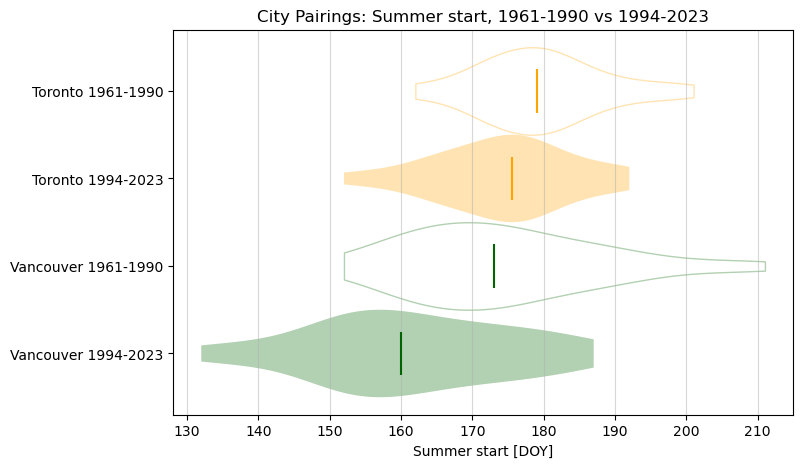

In [30]:
# violin plot customization from https://stackoverflow.com/questions/26291479/changing-the-color-of-matplotlibs-violin-plots
labels=['Vancouver 1994-2023','Vancouver 1961-1990',
        'Toronto 1994-2023','Toronto 1961-1990'
        ]

colors = ['darkgreen','darkgreen','orange','orange']#,'gray','gray','red','red','purple','purple']
data = [van_start_analysis, van_start_base, 
        tor_start_analysis, tor_start_base
       ]


fig, ax = plt.subplots(1, 1, figsize=(8,5))
plots = ax.violinplot(data, vert=False, showmedians=True, showextrema=False, widths=1)
for i, (pc,color) in enumerate(zip(plots['bodies'], colors)):
    if i % 2 == 0:
        pc.set_facecolor(color)
    else:
        pc.set_edgecolor(color)
        pc.set_facecolor('white')

# Set the color of the median lines
plots['cmedians'].set_colors(colors)

ax.set_xlabel("Summer start [DOY]")
ax.set_yticks(np.arange(1,len(labels)+1),labels=labels)
#ax.set_xticks(np.arange(140,300,10))
plt.grid(axis="x", which='both', alpha=0.5)
plt.title("City Pairings: Summer start, 1961-1990 vs 1994-2023")
plt.show()


In [14]:
print("Toronto Change in Median Summer start: " + str(float(tor_start_analysis.median() - tor_start_base.median())) + " days")
print("Van Change in Median Summer start: " + str(float(van_start_analysis.median() - van_start_base.median())) + " days")

Toronto Change in Median Summer start: -3.5 days
Van Change in Median Summer start: -13.0 days


#### Beijing vs Guangzhou

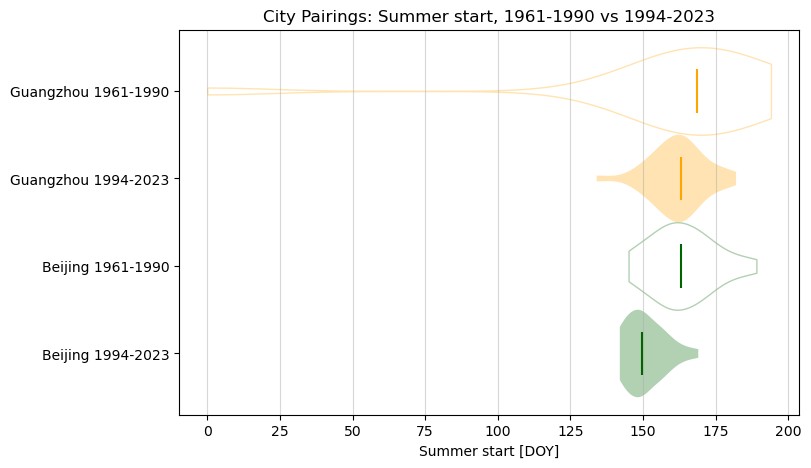

In [31]:
# violin plot customization from https://stackoverflow.com/questions/26291479/changing-the-color-of-matplotlibs-violin-plots
labels=['Beijing 1994-2023','Beijing 1961-1990',
        'Guangzhou 1994-2023','Guangzhou 1961-1990'
        ]

colors = ['darkgreen','darkgreen','orange','orange']#,'gray','gray','red','red','purple','purple']
data = [bei_start_analysis, bei_start_base, 
        gua_start_analysis, gua_start_base
       ]


fig, ax = plt.subplots(1, 1, figsize=(8,5))
plots = ax.violinplot(data, vert=False, showmedians=True, showextrema=False, widths=1)
for i, (pc,color) in enumerate(zip(plots['bodies'], colors)):
    if i % 2 == 0:
        pc.set_facecolor(color)
    else:
        pc.set_edgecolor(color)
        pc.set_facecolor('white')

# Set the color of the median lines
plots['cmedians'].set_colors(colors)

ax.set_xlabel("Summer start [DOY]")
ax.set_yticks(np.arange(1,len(labels)+1),labels=labels)
#ax.set_xticks(np.arange(140,300,10))
plt.grid(axis="x", which='both', alpha=0.5)
plt.title("City Pairings: Summer start, 1961-1990 vs 1994-2023")
plt.show()


In [16]:
print("Beijing Change in Median Summer start: " + str(float(bei_start_analysis.median() - bei_start_base.median())) + " days")
print("Guangzhou Change in Median Summer start: " + str(float(gua_start_analysis.median() - gua_start_base.median())) + " days")

Beijing Change in Median Summer start: -13.5 days
Guangzhou Change in Median Summer start: -5.5 days


#### Phoenix vs New Delhi

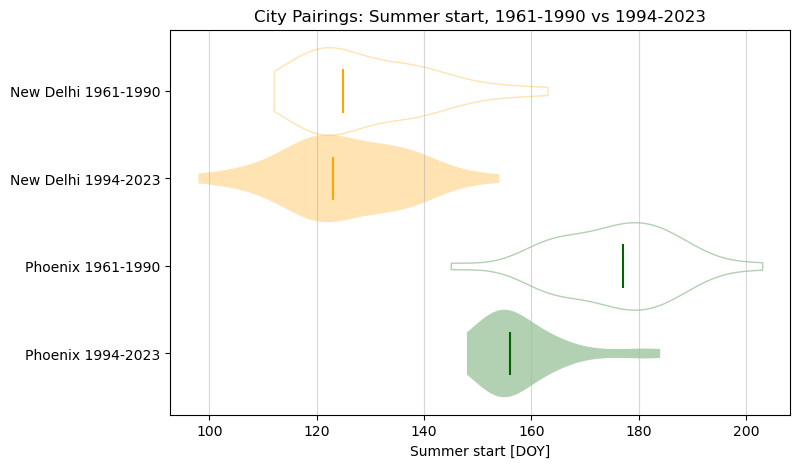

In [32]:
# violin plot customization from https://stackoverflow.com/questions/26291479/changing-the-color-of-matplotlibs-violin-plots
labels=['Phoenix 1994-2023','Phoenix 1961-1990',
        'New Delhi 1994-2023','New Delhi 1961-1990'
        ]

colors = ['darkgreen','darkgreen','orange','orange']#,'gray','gray','red','red','purple','purple']
data = [phx_start_analysis, phx_start_base, 
        nwd_start_analysis, nwd_start_base
       ]


fig, ax = plt.subplots(1, 1, figsize=(8,5))
plots = ax.violinplot(data, vert=False, showmedians=True, showextrema=False, widths=1)
for i, (pc,color) in enumerate(zip(plots['bodies'], colors)):
    if i % 2 == 0:
        pc.set_facecolor(color)
    else:
        pc.set_edgecolor(color)
        pc.set_facecolor('white')

# Set the color of the median lines
plots['cmedians'].set_colors(colors)

ax.set_xlabel("Summer start [DOY]")
ax.set_yticks(np.arange(1,len(labels)+1),labels=labels)
#ax.set_xticks(np.arange(140,300,10))
plt.grid(axis="x", which='both', alpha=0.5)
plt.title("City Pairings: Summer start, 1961-1990 vs 1994-2023")
plt.show()


In [34]:
print("New Delhi Change in Median Summer start: " + str(float(nwd_start_analysis.median() - nwd_start_base.median())) + " days")
print("Phoenix Change in Median Summer start: " + str(float(phx_start_analysis.median() - phx_start_base.median())) + " days")

New Delhi Change in Median Summer start: -2.0 days
Phoenix Change in Median Summer start: -21.0 days


In [35]:
nwd_start_analysis.median(), phx_start_analysis.median()

(<xarray.DataArray 'SummerStart' ()> Size: 8B
 array(123.)
 Coordinates:
     lat      float64 8B 28.5
     lon      float64 8B 77.25,
 <xarray.DataArray 'SummerStart' ()> Size: 8B
 array(156.)
 Coordinates:
     lat      float64 8B 33.5
     lon      float64 8B -112.0)

## Summer End Data for violin and scatter plots

In [36]:
ds_base = ds_full_end.sel(time=slice('1961','1990'))
ds = ds_full_end.sel(time=slice('1994','2023'))

Van p-val: 0.0002
Tor p-val: 0.003
Bei p-val: 0.0
Gua p-val: 0.0333
Syd p-val: 0.0364
CTn p-val: 0.9606
Phx p-val: 0.0
NwD p-val: 0.0395


(220.0, 300.0)

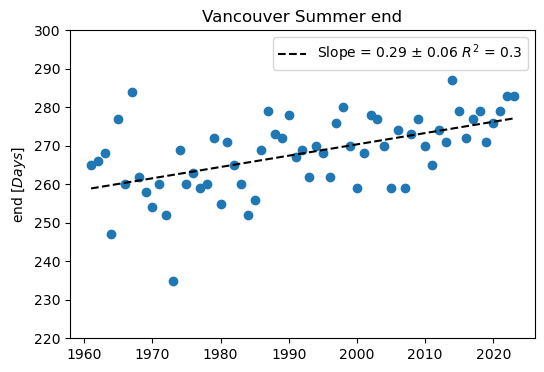

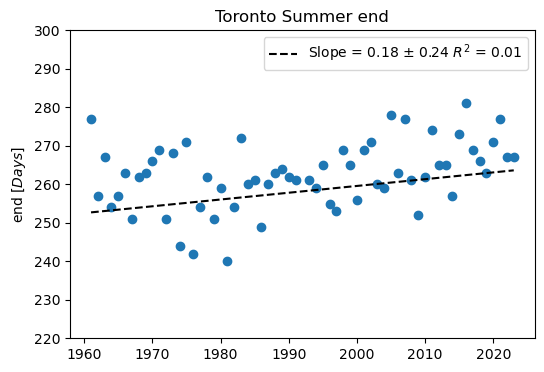

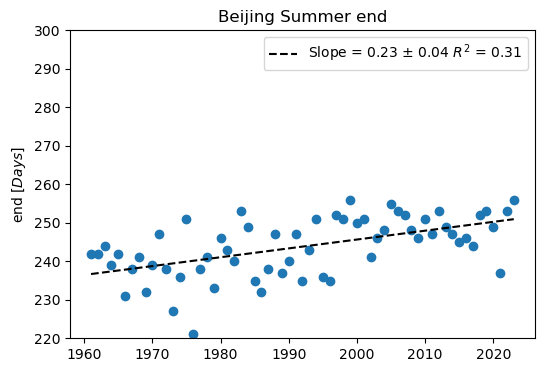

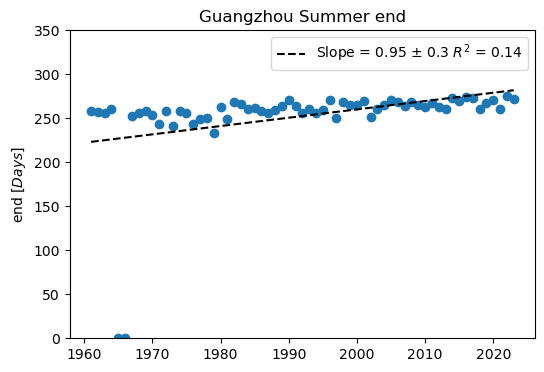

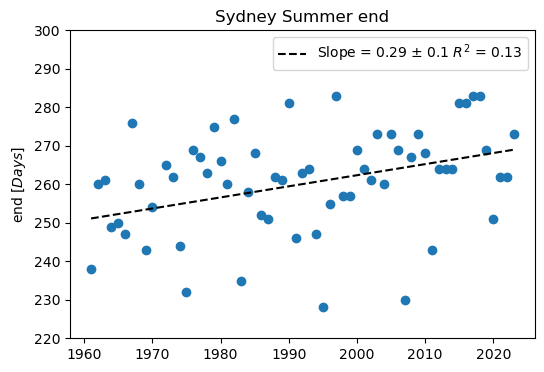

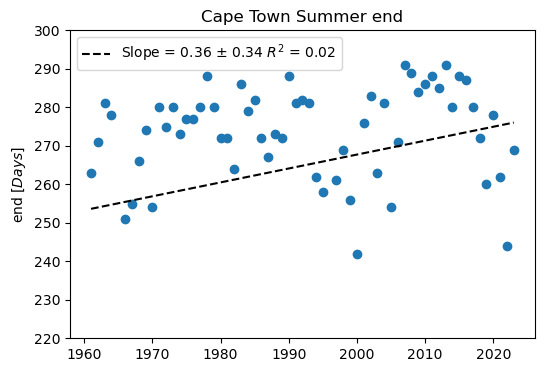

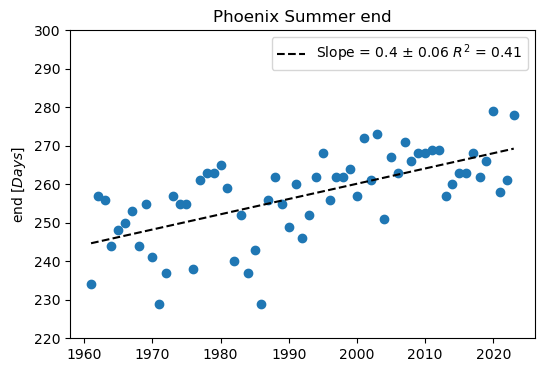

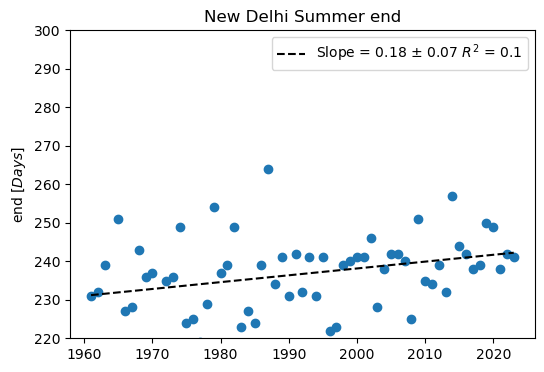

In [40]:

# Vancouver
input_lat = 49.246
input_lon = -123.116
van_end_analysis = ds.sel(lat=input_lat, lon=input_lon, method="nearest")
van_end_base = ds_base.sel(lat=input_lat, lon=input_lon, method="nearest")
# t-test
statres, pval = stats.ttest_rel(van_end_analysis, van_end_base)
print("Van p-val: "+str(np.round(pval,4)))

# plot the time series of Summer end for Vancouver w/ linear fit
x = ds_full_end.time.dt.year.values
y = ds_full_end.sel(lat=input_lat, lon=input_lon, method='nearest').values
coefs, V = np.polyfit(x, y, 1, cov=True)
poly = np.poly1d(coefs)
slope = np.round(coefs[0],2)
slope_sd = np.round(np.sqrt(V[0][0]),2)  
# add in R^2 and RMSE
ymean = np.mean(y)
ss_total = np.sum((y - ymean)**2)
ss_res = np.sum((y - poly(x))**2)
#rmse = np.sqrt(ss_res/365.0)
r_squared = np.round(1 - (ss_res / ss_total),2)
plt.figure(figsize=(6,4))
plt.scatter(x, y)
plt.plot(x, poly(x), linestyle="dashed", color='k', 
         label="Slope = "+str(slope)+" $\pm$ "+str(slope_sd)+" $R^2$ = "+str(r_squared))
plt.title("Vancouver Summer end")
plt.ylabel("end [$Days$]")
plt.legend(loc='best')
plt.ylim(220,300)

# Toronto
# 43°45'03"N 79°28'55"W is roughly the middle from google earth
input_lat = 43 + 45/60
input_lon = -79 -29/60
tor_end_analysis = ds.sel(lat=input_lat, lon=input_lon, method="nearest")
tor_end_base = ds_base.sel(lat=input_lat, lon=input_lon, method="nearest")
# t-test
statres, pval = stats.ttest_rel(tor_end_analysis, tor_end_base)
print("Tor p-val: "+str(np.round(pval,4)))

# plot the time series of Summer end for Toronto
x = ds_full_end.time.dt.year.values
y = ds_full_end.sel(lat=input_lat, lon=input_lon, method='nearest').values
coefs, V = np.polyfit(x, y, 1, cov=True)
poly = np.poly1d(coefs)
slope = np.round(coefs[0],2)
slope_sd = np.round(np.sqrt(V[0][0]),2)  
# add in R^2 and RMSE
ymean = np.mean(y)
ss_total = np.sum((y - ymean)**2)
ss_res = np.sum((y - poly(x))**2)
#rmse = np.sqrt(ss_res/365.0)
r_squared = np.round(1 - (ss_res / ss_total),2)
plt.figure(figsize=(6,4))
plt.scatter(x, y)
plt.plot(x, poly(x), linestyle="dashed", color='k', 
         label="Slope = "+str(slope)+" $\pm$ "+str(slope_sd)+" $R^2$ = "+str(r_squared))
plt.title("Toronto Summer end")
plt.ylabel("end [$Days$]")
plt.legend(loc='best')
plt.ylim(220,300)

# Beijing
input_lat = 39.9075
input_lon = 116.39723
bei_end_analysis = ds.sel(lat=input_lat, lon=input_lon, method="nearest")
bei_end_base = ds_base.sel(lat=input_lat, lon=input_lon, method="nearest")
# t-test
statres, pval = stats.ttest_rel(bei_end_analysis, bei_end_base)
print("Bei p-val: "+str(np.round(pval,4)))

# plot the time series of Summer end for Beijing
x = ds_full_end.time.dt.year.values
y = ds_full_end.sel(lat=input_lat, lon=input_lon, method='nearest').values
coefs, V = np.polyfit(x, y, 1, cov=True)
poly = np.poly1d(coefs)
slope = np.round(coefs[0],2)
slope_sd = np.round(np.sqrt(V[0][0]),2)  
# add in R^2 and RMSE
ymean = np.mean(y)
ss_total = np.sum((y - ymean)**2)
ss_res = np.sum((y - poly(x))**2)
#rmse = np.sqrt(ss_res/365.0)
r_squared = np.round(1 - (ss_res / ss_total),2)
plt.figure(figsize=(6,4))
plt.scatter(x, y)
plt.plot(x, poly(x), linestyle="dashed", color='k', 
         label="Slope = "+str(slope)+" $\pm$ "+str(slope_sd)+" $R^2$ = "+str(r_squared))
plt.title("Beijing Summer end")
plt.ylabel("end [$Days$]")
plt.legend(loc='best')
plt.ylim(220,300)


# Guangzhou
# 112° 57′ to 114° 03′ E longitude and 22° 26′ to 23° 56′ N latitude
input_lat = 22 + 45/60 # midpoint of those latitude values above
input_lon = 113.5 # midpoint of those longitudes above
gua_end_analysis = ds.sel(lat=input_lat, lon=input_lon, method="nearest")
gua_end_base = ds_base.sel(lat=input_lat, lon=input_lon, method="nearest")
# t-test
statres, pval = stats.ttest_rel(gua_end_analysis, gua_end_base)
print("Gua p-val: "+str(np.round(pval,4)))

# plot the time series of Summer end for Guangzhou
x = ds_full_end.time.dt.year.values
y = ds_full_end.sel(lat=input_lat, lon=input_lon, method='nearest').values
coefs, V = np.polyfit(x, y, 1, cov=True)
poly = np.poly1d(coefs)
slope = np.round(coefs[0],2)
slope_sd = np.round(np.sqrt(V[0][0]),2)  
# add in R^2 and RMSE
ymean = np.mean(y)
ss_total = np.sum((y - ymean)**2)
ss_res = np.sum((y - poly(x))**2)
#rmse = np.sqrt(ss_res/365.0)
r_squared = np.round(1 - (ss_res / ss_total),2)
plt.figure(figsize=(6,4))
plt.scatter(x, y)
plt.plot(x, poly(x), linestyle="dashed", color='k', 
         label="Slope = "+str(slope)+" $\pm$ "+str(slope_sd)+" $R^2$ = "+str(r_squared))
plt.title("Guangzhou Summer end")
plt.ylabel("end [$Days$]")
plt.legend(loc='best')
plt.ylim(0,350)

# Sydney, NSW
input_lat = -33.86785
input_lon = 151.083
syd_end_analysis = ds.sel(lat=input_lat, lon=input_lon, method="nearest")
syd_end_base = ds_base.sel(lat=input_lat, lon=input_lon, method="nearest")
# t-test
statres, pval = stats.ttest_rel(syd_end_analysis, syd_end_base)
print("Syd p-val: "+str(np.round(pval,4)))

# plot the time series of Summer end for Sydney
x = ds_full_end.time.dt.year.values
y = ds_full_end.sel(lat=input_lat, lon=input_lon, method='nearest').values
coefs, V = np.polyfit(x, y, 1, cov=True)
poly = np.poly1d(coefs)
slope = np.round(coefs[0],2)
slope_sd = np.round(np.sqrt(V[0][0]),2)  
# add in R^2 and RMSE
ymean = np.mean(y)
ss_total = np.sum((y - ymean)**2)
ss_res = np.sum((y - poly(x))**2)
#rmse = np.sqrt(ss_res/365.0)
r_squared = np.round(1 - (ss_res / ss_total),2)
plt.figure(figsize=(6,4))
plt.scatter(x, y)
plt.plot(x, poly(x), linestyle="dashed", color='k', 
         label="Slope = "+str(slope)+" $\pm$ "+str(slope_sd)+" $R^2$ = "+str(r_squared))
plt.title("Sydney Summer end")
plt.ylabel("end [$Days$]")
plt.legend(loc='best')
plt.ylim(220,300)

# Cape Town
input_lat = -33.95
input_lon = 18+32/60
ctn_end_analysis = ds.sel(lat=input_lat, lon=input_lon, method="nearest")
ctn_end_base = ds_base.sel(lat=input_lat, lon=input_lon, method="nearest")
# t-test
statres, pval = stats.ttest_rel(ctn_end_analysis, ctn_end_base)
print("CTn p-val: "+str(np.round(pval,4)))

# plot the time series of Summer end for Cape Town
x = ds_full_end.time.dt.year.values
y = ds_full_end.sel(lat=input_lat, lon=input_lon, method='nearest').values
coefs, V = np.polyfit(x, y, 1, cov=True)
poly = np.poly1d(coefs)
slope = np.round(coefs[0],2)
slope_sd = np.round(np.sqrt(V[0][0]),2)  
# add in R^2 and RMSE
ymean = np.mean(y)
ss_total = np.sum((y - ymean)**2)
ss_res = np.sum((y - poly(x))**2)
#rmse = np.sqrt(ss_res/365.0)
r_squared = np.round(1 - (ss_res / ss_total),2)
plt.figure(figsize=(6,4))
plt.scatter(x, y)
plt.plot(x, poly(x), linestyle="dashed", color='k', 
         label="Slope = "+str(slope)+" $\pm$ "+str(slope_sd)+" $R^2$ = "+str(r_squared))
plt.title("Cape Town Summer end")
plt.ylabel("end [$Days$]")
plt.legend(loc='best')
plt.ylim(220,300)

# Phoenix
input_lat = 33+28/60
input_lon = -112 - 4/60
phx_end_analysis = ds.sel(lat=input_lat, lon=input_lon, method="nearest")
phx_end_base = ds_base.sel(lat=input_lat, lon=input_lon, method="nearest")
# t-test
statres, pval = stats.ttest_rel(phx_end_analysis, phx_end_base)
print("Phx p-val: "+str(np.round(pval,4)))

# plot the time series of Summer end for Phoenix
x = ds_full_end.time.dt.year.values
y = ds_full_end.sel(lat=input_lat, lon=input_lon, method='nearest').values
coefs, V = np.polyfit(x, y, 1, cov=True)
poly = np.poly1d(coefs)
slope = np.round(coefs[0],2)
slope_sd = np.round(np.sqrt(V[0][0]),2)  
# add in R^2 and RMSE
ymean = np.mean(y)
ss_total = np.sum((y - ymean)**2)
ss_res = np.sum((y - poly(x))**2)
#rmse = np.sqrt(ss_res/365.0)
r_squared = np.round(1 - (ss_res / ss_total),2)
plt.figure(figsize=(6,4))
plt.scatter(x, y)
plt.plot(x, poly(x), linestyle="dashed", color='k', 
         label="Slope = "+str(slope)+" $\pm$ "+str(slope_sd)+" $R^2$ = "+str(r_squared))
plt.title("Phoenix Summer end")
plt.ylabel("end [$Days$]")
plt.legend(loc='best')
plt.ylim(220,300)

# New Delhi
input_lat = 28+37/60
input_lon = 77 + 13/60
nwd_end_analysis = ds.sel(lat=input_lat, lon=input_lon, method="nearest")
nwd_end_base = ds_base.sel(lat=input_lat, lon=input_lon, method="nearest")
# t-test
statres, pval = stats.ttest_rel(nwd_end_analysis, nwd_end_base)
print("NwD p-val: "+str(np.round(pval,4)))

# plot the time series of Summer end for New Delhi
x = ds_full_end.time.dt.year.values
y = ds_full_end.sel(lat=input_lat, lon=input_lon, method='nearest').values
coefs, V = np.polyfit(x, y, 1, cov=True)
poly = np.poly1d(coefs)
slope = np.round(coefs[0],2)
slope_sd = np.round(np.sqrt(V[0][0]),2)  
# add in R^2 and RMSE
ymean = np.mean(y)
ss_total = np.sum((y - ymean)**2)
ss_res = np.sum((y - poly(x))**2)
#rmse = np.sqrt(ss_res/365.0)
r_squared = np.round(1 - (ss_res / ss_total),2)
plt.figure(figsize=(6,4))
plt.scatter(x, y)
plt.plot(x, poly(x), linestyle="dashed", color='k', 
         label="Slope = "+str(slope)+" $\pm$ "+str(slope_sd)+" $R^2$ = "+str(r_squared))
plt.title("New Delhi Summer end")
plt.ylabel("end [$Days$]")
plt.legend(loc='best')
plt.ylim(220,300)
